This is a very interesting task and it's very suitable for beginners, through this task you can learn about data analysis, data processing, model building, model training, parameter optimization and so on. When only use the images, with a common network, such as Resnet, Densenet, you can achieve a relatively good accuracy very easily. 

By analyzing the data, the basic information of the patient is also related to the classification of the diseased tissue. Therefore, if we can combine the case information to carry out the classification task, it will be a very meaningful work. Actually during clinical diagnosis, doctors will also combine different modal data to make comprehensive judgments.

Due to the urgency of time, my current method only uses image data, and then I will consider adding the patient's personal information to the classification task to train a more complete model. I will update my kernel immediately once I finished.

Before you really start, I strongly recommend you to read the material of pigmented lesions and dermatoscopic images[https://arxiv.org/abs/1803.10417]. After that, you can learn about the characteristics and distribution of the data from the task description and this kernel[https://www.kaggle.com/kmader/dermatology-mnist-loading-and-processing]

In this kernel I have followed following steps for model building and evaluation: 

> Step 1. Data analysis and preprocessing

> Step 2. Model building

> Step 3. Model training

> Step 4. Model evaluation

I used the pytorch framework to complete the entire task. The code contains several common networks, such as Resnet, VGG, Densenet, and Inception. You only need to make minor changes on the code to complete the network switch. Without the hyperparameter adjustment, I used **Densenet-121 to achieve an accuracy of more than 90% on the validation set in 10 epochs.**



In [1]:
import random
import torch
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

 ### First, import all libraries that used in this project

In [2]:
%matplotlib inline
# python libraties
import os, cv2,itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image

# pytorch libraries
import torch
from torch import optim,nn
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset
from torchvision import models,transforms

# sklearn libraries
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print(os.listdir("../data"))
import copy


['HAM10000_images_part_2', 'DDI', 'HAM10000_images_part_1', 'fitzpatrick17k', 'HAM10000_metadata.csv']


## Step 1. Data analysis and preprocessing

Get the all image data paths， match the row information in HAM10000_metadata.csv with its corresponding image

In [3]:
data_dir = '../data'
all_image_path = glob(os.path.join(data_dir, '*', '*.jpg'))
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}

# dx短縮名 → 表示名
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# dx短縮名 → クラスインデックス（この定義が全セルの唯一の真実）
dx_to_idx = {
    'akiec': 0,
    'bcc':   1,
    'bkl':   2,
    'df':    3,
    'mel':   4,
    'nv':    5,
    'vasc':  6,
}
idx_to_dx = {v: k for k, v in dx_to_idx.items()}
class_names = [idx_to_dx[i] for i in range(len(dx_to_idx))]
# → ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

This function is used to compute the mean and standard deviation on the whole dataset, will use for inputs normalization

In [4]:
def compute_img_mean_std(image_paths):
    """
        computing the mean and std of three channel on the whole dataset,
        first we should normalize the image from 0-255 to 0-1
    """

    img_h, img_w = 224, 224
    imgs = []
    means, stdevs = [], []

    for i in tqdm(range(len(image_paths))):
        img = cv2.imread(image_paths[i])
        img = cv2.resize(img, (img_h, img_w))
        imgs.append(img)

    imgs = np.stack(imgs, axis=3)
    print(imgs.shape)

    imgs = imgs.astype(np.float32) / 255.

    for i in range(3):
        pixels = imgs[:, :, i, :].ravel()  # resize to one row
        means.append(np.mean(pixels))
        stdevs.append(np.std(pixels))

    means.reverse()  # BGR --> RGB
    stdevs.reverse()

    print("normMean = {}".format(means))
    print("normStd = {}".format(stdevs))
    return means,stdevs

Return the mean and std of RGB channels

In [5]:
norm_mean,norm_std = compute_img_mean_std(all_image_path)

100%|█████████████████████████████████████████████████████████| 10015/10015 [00:31<00:00, 318.47it/s]


(224, 224, 3, 10015)
normMean = [np.float32(0.7630378), np.float32(0.5456452), np.float32(0.5700444)]
normStd = [np.float32(0.1409281), np.float32(0.15261304), np.float32(0.16997081)]


Add three columns to the original DataFrame, path (image path), cell_type (the whole name),cell_type_idx (the corresponding index  of cell type, as the image label )

In [6]:
df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
df_original['cell_type_idx'] = df_original['dx'].map(dx_to_idx)  # ← pd.Categoricalを廃止
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0027419.jpg,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025030.jpg,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0026769.jpg,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025661.jpg,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/HAM10000_images_part_2/ISIC_0031633.jpg,Benign keratosis-like lesions,2


In [7]:
# this will tell us how many images are associated with each lesion_id
df_undup = df_original.groupby('lesion_id').count()
# now we filter out lesion_id's that have only one image associated with it
df_undup = df_undup[df_undup['image_id'] == 1]
df_undup.reset_index(inplace=True)
df_undup.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000001,1,1,1,1,1,1,1,1,1
1,HAM_0000003,1,1,1,1,1,1,1,1,1
2,HAM_0000004,1,1,1,1,1,1,1,1,1
3,HAM_0000007,1,1,1,1,1,1,1,1,1
4,HAM_0000008,1,1,1,1,1,1,1,1,1


In [8]:
# here we identify lesion_id's that have duplicate images and those that have only one image.
def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    if x in unique_list:
        return 'unduplicated'
    else:
        return 'duplicated'

# create a new colum that is a copy of the lesion_id column
df_original['duplicates'] = df_original['lesion_id']
# apply the function to this new column
df_original['duplicates'] = df_original['duplicates'].apply(get_duplicates)
df_original.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx,duplicates
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0027419.jpg,Benign keratosis-like lesions,2,duplicated
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025030.jpg,Benign keratosis-like lesions,2,duplicated
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0026769.jpg,Benign keratosis-like lesions,2,duplicated
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025661.jpg,Benign keratosis-like lesions,2,duplicated
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/HAM10000_images_part_2/ISIC_0031633.jpg,Benign keratosis-like lesions,2,duplicated


In [9]:
df_original['duplicates'].value_counts()

duplicates
unduplicated    5514
duplicated      4501
Name: count, dtype: int64

In [10]:
# now we filter out images that don't have duplicates
df_undup = df_original[df_original['duplicates'] == 'unduplicated']
df_undup.shape

(5514, 11)

In [11]:
# now we create a val set using df because we are sure that none of these images have augmented duplicates in the train set
y = df_undup['cell_type_idx']
_, df_val = train_test_split(df_undup, test_size=0.2, random_state=101, stratify=y)
df_val.shape

(1103, 11)

In [12]:
df_val['cell_type_idx'].value_counts()

cell_type_idx
5    883
2     88
4     46
1     35
0     30
6     13
3      8
Name: count, dtype: int64

In [13]:
# This set will be df_original excluding all rows that are in the val set
# This function identifies if an image is part of the train or val set.
def get_val_rows(x):
    # create a list of all the lesion_id's in the val set
    val_list = list(df_val['image_id'])
    if str(x) in val_list:
        return 'val'
    else:
        return 'train'

# identify train and val rows
# create a new colum that is a copy of the image_id column
df_original['train_or_val'] = df_original['image_id']
# apply the function to this new column
df_original['train_or_val'] = df_original['train_or_val'].apply(get_val_rows)
# filter out train rows
df_train = df_original[df_original['train_or_val'] == 'train']
print(len(df_train))
print(len(df_val))

8912
1103


In [14]:
df_train['cell_type_idx'].value_counts()

cell_type_idx
5    5822
4    1067
2    1011
1     479
0     297
6     129
3     107
Name: count, dtype: int64

In [15]:
df_val['cell_type'].value_counts()

cell_type
Melanocytic nevi                 883
Benign keratosis-like lesions     88
Melanoma                          46
Basal cell carcinoma              35
Actinic keratoses                 30
Vascular lesions                  13
Dermatofibroma                     8
Name: count, dtype: int64

**From From the above statistics of each category, we can see that there is a serious class imbalance in the training data. To solve this problem, I think we can start from two aspects, one is equalization sampling, and the other is a loss function that can be used to mitigate category imbalance during training, such as focal loss.**

In [16]:
data_aug_rate = [15, 10, 5, 50, 5, 0, 40]
for i in range(7):
    if data_aug_rate[i]:
        df_train = pd.concat([df_train] + [df_train.loc[df_train['cell_type_idx'] == i,:]] * (data_aug_rate[i]-1), ignore_index=True)
df_train['cell_type'].value_counts()

cell_type
Melanocytic nevi                 5822
Dermatofibroma                   5350
Melanoma                         5335
Vascular lesions                 5160
Benign keratosis-like lesions    5055
Basal cell carcinoma             4790
Actinic keratoses                4455
Name: count, dtype: int64

At the beginning, I divided the data into three parts, training set, validation set and test set. Considering the small amount of data, I did not further divide the validation set data in practice.

In [17]:
# # We can split the test set again in a validation set and a true test set:
# df_val, df_test = train_test_split(df_val, test_size=0.5)
df_train = df_train.reset_index()
df_val = df_val.reset_index()
# df_test = df_test.reset_index()

## Step 2. Model building

In [18]:
# feature_extract is a boolean that defines if we are finetuning or feature extracting. 
# If feature_extract = False, the model is finetuned and all model parameters are updated. 
# If feature_extract = True, only the last layer parameters are updated, the others remain fixed.
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [19]:
# ============================================================
# CNN (Convolutional Neural Network) モデルの初期化
# ------------------------------------------------------------
# CNNは画像認識に特化したニューラルネットワーク。
# 小さなフィルター（例：3×3）を画像上でスライドさせて特徴を抽出する（=畳み込み）。
# 浅い層→エッジや色の境界、深い層→「ほくろっぽい形」等の高レベル概念を検出。
# 最終層で「この画像はクラスAの確率○%...」と分類する。
#
# 以下の全モデル（ResNet, VGG, DenseNet, Inception, EfficientNet）はCNNの一種。
# 違いは層のつなぎ方やスケーリング方法であり、基本構造は同じ。
#
# Transfer Learning:
#   ImageNet（一般画像1.28M枚）で学習済みの特徴抽出能力を流用し、
#   最終分類層だけ「皮膚疾患7クラス」に差し替えて再学習する。
# ============================================================
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0
    if model_name == "resnet":
        # ResNet50: 残差接続（skip connection）で勾配消失を防ぐ。2015年。
        model_ft = models.resnet50(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)  # 最終全結合層を7クラスに差替
        input_size = 224
    elif model_name == "vgg":
        # VGG11: 小さい3×3フィルターを深く積む素朴な設計。2014年。パラメータ数が多い。
        model_ft = models.vgg11_bn(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)  # classifier層の最後を差替
        input_size = 224
    elif model_name == "densenet":
        # DenseNet-121: 各層が以前の全層の出力を受け取る（Dense Connection）。
        # 勾配が消えにくく特徴の再利用効率が高い。2017年。8.0Mパラメータ。
        # → このNotebookの元々のベースラインモデル（val acc 0.895）
        model_ft = models.densenet121(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)  # classifierが直接Linear
        input_size = 224
    elif model_name == "inception":
        # Inception v3: 複数サイズのフィルターを並列実行。Esteva論文で使用。2015年。
        # 入力サイズが299×299で他と異なる。補助出力（AuxLogits）も差替が必要。
        model_ft = models.inception_v3(weights='IMAGENET1K_V1' if use_pretrained else None)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(num_ftrs, num_classes)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        input_size = 299
    elif model_name == "efficientnet":
        # EfficientNet-B0: 幅・深さ・解像度を最適バランスで同時スケール。2019年。
        # DenseNetより少ないパラメータ（5.3M）で同等以上の精度。
        # → DenseNetベースラインとの比較用に追加
        # classifier構造: Sequential(Dropout[0] → Linear[1]) なので[1]を差替
        model_ft = models.efficientnet_b0(weights='IMAGENET1K_V1')
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[1].in_features
        model_ft.classifier[1] = nn.Linear(num_ftrs, num_classes)
        input_size = 224
    else:
        print("Invalid model name, exiting...")
        exit()
    return model_ft, input_size

You can change your backbone network, here are 4 different networks, each network also has sevaral versions. Considering the limited training data, we used the ImageNet pre-training model for fine-tuning. This can speed up the convergence of the model and improve the accuracy.

There is one thing you need to pay attention to, the input size of Inception is different from the others (299x299), you need to change the setting of compute_img_mean_std() function 

In [20]:
# ============================================================
# モデル切替手順
# ------------------------------------------------------------
# 1. model_nameを変更（'densenet', 'efficientnet', 'resnet'）
# 2. Kernel → Restart Kernel and Run All Cells で全セル実行
#    ※途中セルだけ再実行するとシード状態がずれて比較条件が崩れる
# 3. 結果は results/v2/ に自動保存される
# ============================================================

import gc
if 'model' in dir():
    del model
if 'model_ft' in dir():
    del model_ft
gc.collect()
torch.cuda.empty_cache()

model_name = 'densenet'
num_classes = 7
feature_extract = False
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)
device = torch.device('cuda:0')
model = model_ft.to(device)
del model_ft

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs (DataParallel)')
    model = nn.DataParallel(model)

print(f'Model: {model_name}, input_size: {input_size}')
print(f'Params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')
print(f'GPU memory: {torch.cuda.memory_allocated()/1e6:.0f}MB allocated')


Using 2 GPUs (DataParallel)
Model: densenet, input_size: 224
Params: 7.0M
GPU memory: 28MB allocated


In [21]:
# norm_mean = (0.49139968, 0.48215827, 0.44653124)
# norm_std = (0.24703233, 0.24348505, 0.26158768)
# define the transformation of the train images.
train_transform = transforms.Compose([transforms.Resize((input_size,input_size)),transforms.RandomHorizontalFlip(),
                                      transforms.RandomVerticalFlip(),transforms.RandomRotation(20),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1, hue=0.1),
                                        transforms.ToTensor(), transforms.Normalize(norm_mean, norm_std)])
# define the transformation of the val images.
val_transform = transforms.Compose([transforms.Resize((input_size,input_size)), transforms.ToTensor(),
                                    transforms.Normalize(norm_mean, norm_std)])

In [22]:
# Define a pytorch dataloader for this dataset
class HAM10000(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load data and get label
        X = Image.open(self.df['path'][index])
        y = torch.tensor(int(self.df['cell_type_idx'][index]))

        if self.transform:
            X = self.transform(X)

        return X, y

In [23]:
# Define the training set using the table train_df and using our defined transitions (train_transform)
training_set = HAM10000(df_train, transform=train_transform)
train_loader = DataLoader(training_set, batch_size=64, shuffle=True, num_workers=4)
# Same for the validation set:
validation_set = HAM10000(df_val, transform=val_transform)
val_loader = DataLoader(validation_set, batch_size=64, shuffle=False, num_workers=4)

In [24]:
# we use Adam optimizer, use cross entropy loss as our loss function
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss().to(device)

# LR Scheduler: val lossが3epoch改善しなければLRを1/10に減衰
# epoch 10以降の学習を安定させるために必須
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


## Step 3. Model training

In [25]:
# this function is used during training process, to calculation the loss and accuracy
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [26]:
total_loss_train, total_acc_train = [],[]
def train(train_loader, model, criterion, optimizer, epoch):
    model.train()
    train_loss = AverageMeter()
    train_acc = AverageMeter()
    curr_iter = (epoch - 1) * len(train_loader)
    for i, data in enumerate(train_loader):
        images, labels = data
        N = images.size(0)
        # print('image shape:',images.size(0), 'label shape',labels.size(0))
        images = Variable(images).to(device)
        labels = Variable(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        prediction = outputs.max(1, keepdim=True)[1]
        train_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)
        train_loss.update(loss.item())
        curr_iter += 1
        if (i + 1) % 100 == 0:
            print('[epoch %d], [iter %d / %d], [train loss %.5f], [train acc %.5f]' % (
                epoch, i + 1, len(train_loader), train_loss.avg, train_acc.avg))
            total_loss_train.append(train_loss.avg)
            total_acc_train.append(train_acc.avg)
    return train_loss.avg, train_acc.avg

In [27]:
def validate(val_loader, model, criterion, optimizer, epoch):
    model.eval()
    val_loss = AverageMeter()
    val_acc = AverageMeter()
    with torch.no_grad():
        for i, data in enumerate(val_loader):
            images, labels = data
            N = images.size(0)
            images = Variable(images).to(device)
            labels = Variable(labels).to(device)

            outputs = model(images)
            prediction = outputs.max(1, keepdim=True)[1]

            val_acc.update(prediction.eq(labels.view_as(prediction)).sum().item()/N)

            val_loss.update(criterion(outputs, labels).item())

    print('------------------------------------------------------------')
    print('[epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, val_loss.avg, val_acc.avg))
    print('------------------------------------------------------------')
    return val_loss.avg, val_acc.avg

In [28]:
epoch_num = 15
best_val_acc = 0
total_loss_val, total_acc_val = [],[]

import copy

# DataParallel対応: module.state_dict()で保存し、module.load_state_dict()で復元
_model_ref = model.module if hasattr(model, 'module') else model
best_model_wts = copy.deepcopy(_model_ref.state_dict())

for epoch in range(1, epoch_num+1):
    loss_train, acc_train = train(train_loader, model, criterion, optimizer, epoch)
    loss_val, acc_val = validate(val_loader, model, criterion, optimizer, epoch)
    total_loss_val.append(loss_val)
    total_acc_val.append(acc_val)

    scheduler.step(loss_val)

    if acc_val > best_val_acc:
        best_val_acc = acc_val
        _model_ref = model.module if hasattr(model, 'module') else model
        best_model_wts = copy.deepcopy(_model_ref.state_dict())
        print('*****************************************************')
        print('best record: [epoch %d], [val loss %.5f], [val acc %.5f]' % (epoch, loss_val, acc_val))
        print('*****************************************************')

# ベストモデルの重みを復元
_model_ref = model.module if hasattr(model, 'module') else model
_model_ref.load_state_dict(best_model_wts)
del best_model_wts
torch.cuda.empty_cache()
print(f'\nRestored best model weights (val acc {best_val_acc:.5f})')
print(f'GPU memory: {torch.cuda.memory_allocated()/1e6:.0f}MB allocated')


[epoch 1], [iter 100 / 562], [train loss 1.03522], [train acc 0.61891]
[epoch 1], [iter 200 / 562], [train loss 0.91565], [train acc 0.65867]
[epoch 1], [iter 300 / 562], [train loss 0.84644], [train acc 0.68286]
[epoch 1], [iter 400 / 562], [train loss 0.79783], [train acc 0.69992]
[epoch 1], [iter 500 / 562], [train loss 0.75733], [train acc 0.71613]
------------------------------------------------------------
[epoch 1], [val loss 0.37558], [val acc 0.87431]
------------------------------------------------------------
*****************************************************
best record: [epoch 1], [val loss 0.37558], [val acc 0.87431]
*****************************************************
[epoch 2], [iter 100 / 562], [train loss 0.53039], [train acc 0.79781]
[epoch 2], [iter 200 / 562], [train loss 0.51723], [train acc 0.80141]
[epoch 2], [iter 300 / 562], [train loss 0.50589], [train acc 0.80604]
[epoch 2], [iter 400 / 562], [train loss 0.49241], [train acc 0.81180]
[epoch 2], [iter 500

## Step 4. Model evaluation

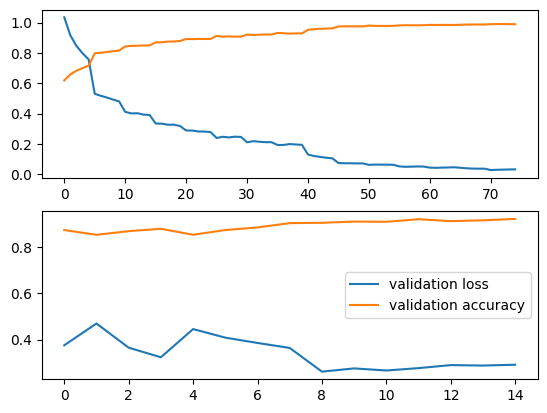

In [29]:
fig = plt.figure(num = 2)
fig1 = fig.add_subplot(2,1,1)
fig2 = fig.add_subplot(2,1,2)
fig1.plot(total_loss_train, label = 'training loss')
fig1.plot(total_acc_train, label = 'training accuracy')
fig2.plot(total_loss_val, label = 'validation loss')
fig2.plot(total_acc_val, label = 'validation accuracy')
plt.legend()
plt.show()

In [30]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

       akiec       0.74      0.67      0.70        30
         bcc       0.89      0.91      0.90        35
         bkl       0.78      0.73      0.75        88
          df       0.70      0.88      0.78         8
         mel       0.48      0.54      0.51        46
          nv       0.97      0.97      0.97       883
        vasc       0.87      1.00      0.93        13

    accuracy                           0.92      1103
   macro avg       0.78      0.81      0.79      1103
weighted avg       0.92      0.92      0.92      1103

ROC-AUC (macro, OvR): 0.9883
  akiec: 0.9905
  bcc: 0.9986
  bkl: 0.9806
  df: 0.9982
  mel: 0.9627
  nv: 0.9878
  vasc: 0.9999


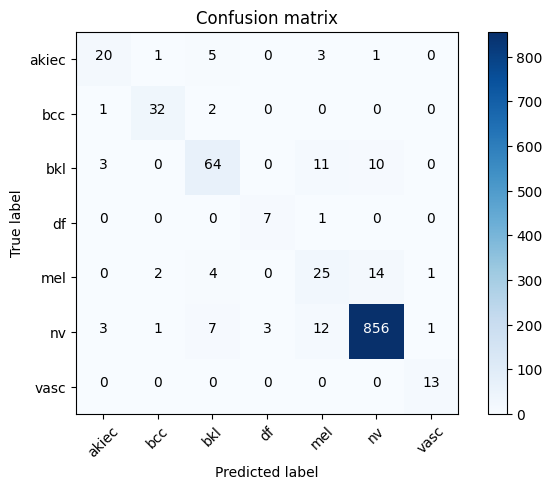

In [31]:
# ============================================================
# 統合評価セル: 1回の推論ループで予測ラベル・softmax確率を同時取得
# ============================================================
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

y_true = []
y_pred = []
y_prob = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        # 予測ラベル
        prediction = outputs.max(1, keepdim=True)[1]
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(np.squeeze(prediction.cpu().numpy().T))

        # softmax確率（ROC-AUC用）
        probs = F.softmax(outputs, dim=1)
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ---- Confusion Matrix ----
confusion_mtx = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(confusion_mtx, class_names)

# ---- Classification Report ----
print(classification_report(y_true, y_pred, target_names=class_names))

# ---- ROC-AUC (macro, One-vs-Rest) ----
y_true_onehot = label_binarize(y_true, classes=range(7))
roc_auc = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")
for i, name in enumerate(class_names):
    auc_i = roc_auc_score(y_true_onehot[:, i], y_prob[:, i])
    print(f"  {name}: {auc_i:.4f}")


Text(0, 0.5, 'Fraction classified incorrectly')

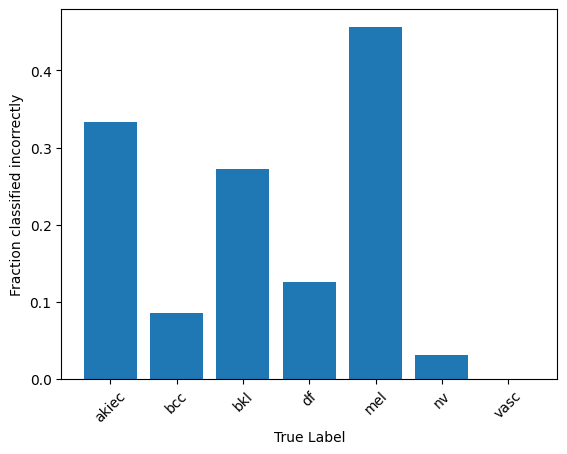

In [32]:
label_frac_error = 1 - np.diag(confusion_mtx) / np.sum(confusion_mtx, axis=1)
plt.bar(np.arange(7), label_frac_error)
plt.xticks(np.arange(7), class_names, rotation=45)
plt.xlabel('True Label')
plt.ylabel('Fraction classified incorrectly')

## Conclusion

I tried to train with different network structures. When using Densenet-121, the average accuracy of 7 classes on the validation set can reach 92% in 10 epochs. We also calculated the confusion matrix for all classes and the F1-score for each class, which is a more comprehensive indicator that can take into account both the precision and recall of the classification model.Our model can achieve more than 90% on the F1-score indicator.

Due to limited time, we did not spend much time on model training. By increasing in training epochs, adjustmenting of model hyperparameters, and attempting at different networks may further enhance the performance of the model.

## Next plan

How to use image data and patient case data at the same time, my plan is to use CNN to extract features from images, use xgboost to convert medical records into vectors and then concat them with CNN network full-layer features. Two branch networks are trained simultaneously using a loss function. We can refer to the methods used in the advertising CTR estimation task.

In [33]:
import os
from datetime import datetime

os.makedirs('../models', exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_path = f'../models/v2_{model_name}_{timestamp}.pth'

# DataParallel対応: module. prefix なしで保存
state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
torch.save(state, save_path)
size_mb = os.path.getsize(save_path) / 1e6
print(f"保存完了: {save_path} ({size_mb:.1f} MB)")
print(f"  model: {model_name}")
print(f"  best val acc: {best_val_acc:.5f}")


保存完了: ../models/v2_densenet_20260311_151147.pth (28.5 MB)
  model: densenet
  best val acc: 0.92251


In [34]:
# ============================================================
# 実験ログ保存（results/v2/ に追記）
# ------------------------------------------------------------
# 実行のたびに結果をJSONに追記し、比較表markdownを自動更新する。
# efficientnet → resnet → densenet の順に実行すれば最後に3モデル比較表が出る。
# ============================================================

import json
import os
from datetime import datetime
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

RESULTS_DIR = '../results/v2'
LOG_JSON = os.path.join(RESULTS_DIR, 'experiment_log.json')
LOG_MD   = os.path.join(RESULTS_DIR, 'experiment_log.md')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── メトリクス計算 ──
y_true_onehot = label_binarize(y_true, classes=range(7))
roc_auc_macro = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
per_class_auc = {
    class_names[i]: round(roc_auc_score(y_true_onehot[:, i], y_prob[:, i]), 4)
    for i in range(7)
}

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
n_params = sum(p.numel() for p in model.parameters()) / 1e6

# ── 全クラスのprecision/recall/f1 ──
per_class_metrics = {}
for c in class_names:
    per_class_metrics[c] = {
        'precision': round(report[c]['precision'], 4),
        'recall':    round(report[c]['recall'], 4),
        'f1':        round(report[c]['f1-score'], 4),
        'support':   int(report[c]['support']),
    }

# ── confusion matrix ──
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

# ── best epoch（訓練ループの記録から復元） ──
best_epoch = int(np.argmax(total_acc_val)) + 1

# ── 1件分のレコード ──
record = {
    'model_name':       model_name,
    'timestamp':        datetime.now().isoformat(),
    'epochs':           epoch_num,
    'best_epoch':       best_epoch,
    'best_val_acc':     round(best_val_acc, 5),
    'roc_auc_macro':    round(roc_auc_macro, 4),
    'per_class_auc':    per_class_auc,
    'per_class_metrics': per_class_metrics,
    'macro_avg': {
        'precision': round(report['macro avg']['precision'], 4),
        'recall':    round(report['macro avg']['recall'], 4),
        'f1':        round(report['macro avg']['f1-score'], 4),
    },
    'weighted_avg': {
        'precision': round(report['weighted avg']['precision'], 4),
        'recall':    round(report['weighted avg']['recall'], 4),
        'f1':        round(report['weighted avg']['f1-score'], 4),
    },
    'confusion_matrix':  cm.tolist(),
    'training_history': {
        'train_loss': [round(x, 5) for x in total_loss_train],
        'train_acc':  [round(x, 5) for x in total_acc_train],
        'val_loss':   [round(x, 5) for x in total_loss_val],
        'val_acc':    [round(x, 5) for x in total_acc_val],
    },
    'params_M':         round(n_params, 1),
    'pth_path':         save_path,
}

# ── JSONに追記 ──
if os.path.exists(LOG_JSON):
    with open(LOG_JSON, 'r') as f:
        logs = json.load(f)
else:
    logs = []
logs.append(record)
with open(LOG_JSON, 'w') as f:
    json.dump(logs, f, indent=2, ensure_ascii=False)

# ── Markdown比較表を生成 ──
md = '# v2 モデル比較実験\n\n'

# 総合メトリクス表
md += '## 総合メトリクス\n\n'
md += '| Model | Params(M) | Best Epoch | Val Acc | ROC-AUC(macro) | Macro P | Macro R | Macro F1 | Weighted F1 |\n'
md += '|-------|-----------|------------|---------|----------------|---------|---------|----------|-------------|\n'
for r in logs:
    md += (
        f'| {r["model_name"]} | {r["params_M"]} | {r["best_epoch"]} '
        f'| {r["best_val_acc"]:.5f} | {r["roc_auc_macro"]:.4f} '
        f'| {r["macro_avg"]["precision"]:.4f} | {r["macro_avg"]["recall"]:.4f} '
        f'| {r["macro_avg"]["f1"]:.4f} | {r["weighted_avg"]["f1"]:.4f} |\n'
    )

# Per-class ROC-AUC表
md += '\n## Per-class ROC-AUC\n\n'
md += '| Model | akiec | bcc | bkl | df | mel | nv | vasc |\n'
md += '|-------|-------|-----|-----|----|-----|-------|------|\n'
for r in logs:
    a = r['per_class_auc']
    md += f'| {r["model_name"]} '
    for c in class_names:
        md += f'| {a[c]:.4f} '
    md += '|\n'

# Per-class Precision表
md += '\n## Per-class Precision\n\n'
md += '| Model | akiec | bcc | bkl | df | mel | nv | vasc |\n'
md += '|-------|-------|-----|-----|----|-----|-------|------|\n'
for r in logs:
    m = r['per_class_metrics']
    md += f'| {r["model_name"]} '
    for c in class_names:
        md += f'| {m[c]["precision"]:.4f} '
    md += '|\n'

# Per-class Recall表
md += '\n## Per-class Recall\n\n'
md += '| Model | akiec | bcc | bkl | df | mel | nv | vasc |\n'
md += '|-------|-------|-----|-----|----|-----|-------|------|\n'
for r in logs:
    m = r['per_class_metrics']
    md += f'| {r["model_name"]} '
    for c in class_names:
        md += f'| {m[c]["recall"]:.4f} '
    md += '|\n'

# Per-class F1表
md += '\n## Per-class F1\n\n'
md += '| Model | akiec | bcc | bkl | df | mel | nv | vasc |\n'
md += '|-------|-------|-----|-----|----|-----|-------|------|\n'
for r in logs:
    m = r['per_class_metrics']
    md += f'| {r["model_name"]} '
    for c in class_names:
        md += f'| {m[c]["f1"]:.4f} '
    md += '|\n'

# Confusion Matrix（モデルごと）
md += '\n## Confusion Matrices\n'
for r in logs:
    md += f'\n### {r["model_name"]}\n\n'
    md += '| |' + '|'.join(f' {c} ' for c in class_names) + '|\n'
    md += '|---|' + '|'.join(['---:'] * 7) + '|\n'
    for i, row_label in enumerate(class_names):
        md += f'| **{row_label}** '
        for j in range(7):
            md += f'| {r["confusion_matrix"][i][j]} '
        md += '|\n'

with open(LOG_MD, 'w') as f:
    f.write(md)

# ── コンソール出力 ──
print(f'\n{"="*60}')
print(f' {model_name} 結果サマリー')
print(f'{"="*60}')
print(f'  Params:         {n_params:.1f}M')
print(f'  Best Epoch:     {best_epoch}/{epoch_num}')
print(f'  Best Val Acc:   {best_val_acc:.5f}')
print(f'  ROC-AUC macro:  {roc_auc_macro:.4f}')
print(f'  Macro  P/R/F1:  {report["macro avg"]["precision"]:.4f} / {report["macro avg"]["recall"]:.4f} / {report["macro avg"]["f1-score"]:.4f}')
print(f'  Weighted F1:    {report["weighted avg"]["f1-score"]:.4f}')
print(f'\n  Per-class:')
print(f'  {"":12} {"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>7} {"N":>5}')
for c in class_names:
    m = per_class_metrics[c]
    a = per_class_auc[c]
    print(f'  {c:12} {m["precision"]:6.4f} {m["recall"]:6.4f} {m["f1"]:6.4f} {a:7.4f} {m["support"]:5d}')
print(f'\n  Confusion Matrix:')
print(f'  {"":12}', ''.join(f'{c:>7}' for c in class_names))
for i, c in enumerate(class_names):
    print(f'  {c:12}', ''.join(f'{cm[i][j]:7d}' for j in range(7)))
print(f'\n{"="*60}')
print(f'  保存先: {LOG_JSON}')
print(f'  比較表: {LOG_MD}')
if len(logs) >= 3:
    print(f'\n  ★ 3モデル揃った！{LOG_MD} に比較表あり')
# ── GPU解放 ──
import gc
if hasattr(model, 'module'):
    model.module.cpu()
else:
    model.cpu()
del model
gc.collect()
torch.cuda.empty_cache()
print(f'\nGPU解放完了: {torch.cuda.memory_allocated()/1e6:.0f}MB allocated')



 densenet 結果サマリー
  Params:         7.0M
  Best Epoch:     15/15
  Best Val Acc:   0.92251
  ROC-AUC macro:  0.9883
  Macro  P/R/F1:  0.7756 / 0.8137 / 0.7919
  Weighted F1:    0.9226

  Per-class:
                 Prec    Rec     F1     AUC     N
  akiec        0.7407 0.6667 0.7018  0.9905    30
  bcc          0.8889 0.9143 0.9014  0.9986    35
  bkl          0.7805 0.7273 0.7529  0.9806    88
  df           0.7000 0.8750 0.7778  0.9982     8
  mel          0.4808 0.5435 0.5102  0.9627    46
  nv           0.9716 0.9694 0.9705  0.9878   883
  vasc         0.8667 1.0000 0.9286  0.9999    13

  Confusion Matrix:
                 akiec    bcc    bkl     df    mel     nv   vasc
  akiec             20      1      5      0      3      1      0
  bcc                1     32      2      0      0      0      0
  bkl                3      0     64      0     11     10      0
  df                 0      0      0      7      1      0      0
  mel                0      2      4      0     25     1